Import Dependencies

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


Data collection and processing


In [4]:
#loading the dataset to pandas dataframe
loan_dataset= pd.read_csv(r'C:\Users\Sanjay\Downloads\train_u6lujuX_CVtuZ9i.csv')


In [5]:
# printing the first 5 rows of the dataframe
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
# number of rows and columns
loan_dataset.shape


(614, 13)

In [7]:
# number of rows and columns
loan_dataset.shape

(614, 13)

In [8]:
# statistical measures
loan_dataset.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
# number of missing values in each column
loan_dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
loan_dataset['Gender'].fillna (loan_dataset['Gender'].mode()[0],inplace=True)
loan_dataset['Married'].fillna(loan_dataset['Married'].mode()[0],inplace=True)
loan_dataset['Dependents'].fillna(loan_dataset['Dependents'].mode()[0],inplace=True)
loan_dataset['Self_Employed'].fillna(loan_dataset['Self_Employed'].mode()[0],inplace=True)
loan_dataset['Loan_Amount_Term'].fillna(loan_dataset['Loan_Amount_Term'].mode()[0],inplace=True)
loan_dataset['Credit_History'].fillna(loan_dataset['Credit_History'].mode()[0],inplace=True)
loan_dataset.head()


C:\Users\Sanjay\AppData\Local\Temp\ipykernel_2984\2775915566.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_dataset['Gender'].fillna (loan_dataset['Gender'].mode()[0],inplace=True)
C:\Users\Sanjay\AppData\Local\Temp\ipykernel_2984\2775915566.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [11]:
loan_dataset.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

C:\Users\Sanjay\AppData\Local\Temp\ipykernel_2984\814491912.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loan_dataset['LoanAmount'])


<Axes: xlabel='LoanAmount', ylabel='Density'>

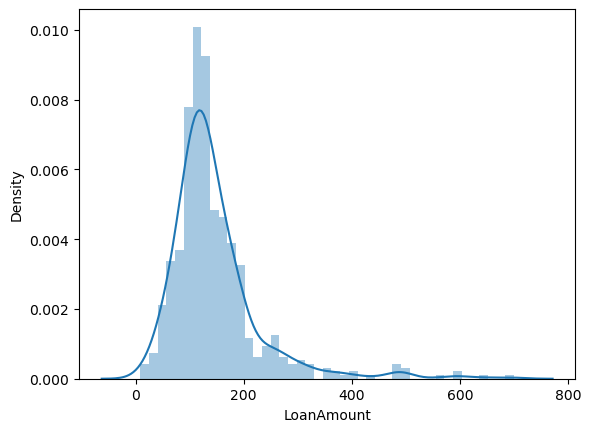

In [12]:
sns.distplot(loan_dataset['LoanAmount'])

Since the data is skewed we use median instead of mode

In [13]:
loan_dataset['LoanAmount'].fillna(loan_dataset['LoanAmount'].median(),inplace=True)

C:\Users\Sanjay\AppData\Local\Temp\ipykernel_2984\2192485212.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_dataset['LoanAmount'].fillna(loan_dataset['LoanAmount'].median(),inplace=True)


In [14]:
loan_dataset.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [15]:
#label encoding
loan_dataset.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)

C:\Users\Sanjay\AppData\Local\Temp\ipykernel_2984\3097104041.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)


In [16]:
# printing the first 5 rows of the dataframe
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [17]:
#Dependent column values 
loan_dataset['Dependents'].value_counts()


Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

In [18]:
loan_dataset.replace({"Dependents":{'3+':4}},inplace=True)
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [19]:
loan_dataset['Dependents'].value_counts()

Dependents
0    360
1    102
2    101
4     51
Name: count, dtype: int64

<Axes: xlabel='Education', ylabel='count'>

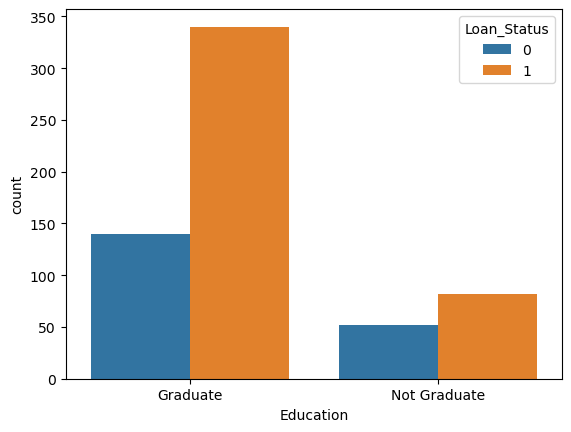

In [20]:
#education and loan status
sns.countplot(x='Education', hue='Loan_Status', data=loan_dataset)

<Axes: xlabel='Married', ylabel='count'>

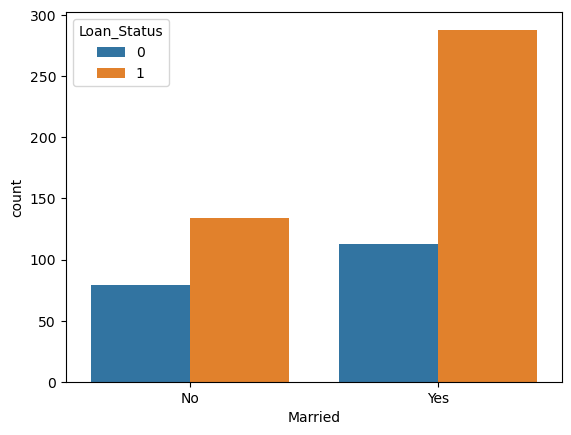

In [21]:
#marital status and loan status
sns.countplot(x= 'Married' , hue='Loan_Status', data=loan_dataset)

<Axes: xlabel='Gender', ylabel='count'>

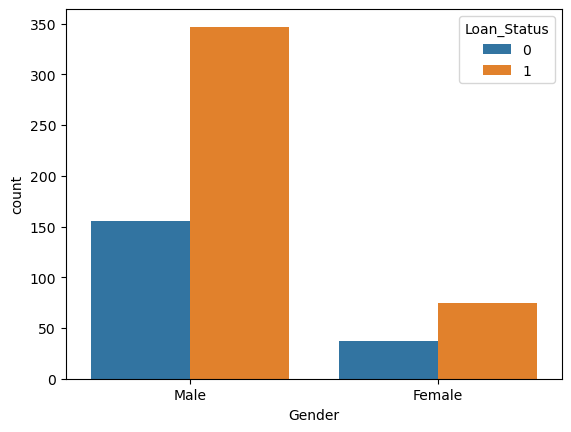

In [22]:
# Gender & Loan Status
sns.countplot(x='Gender',hue='Loan_Status',data=loan_dataset)

<Axes: xlabel='Self_Employed', ylabel='count'>

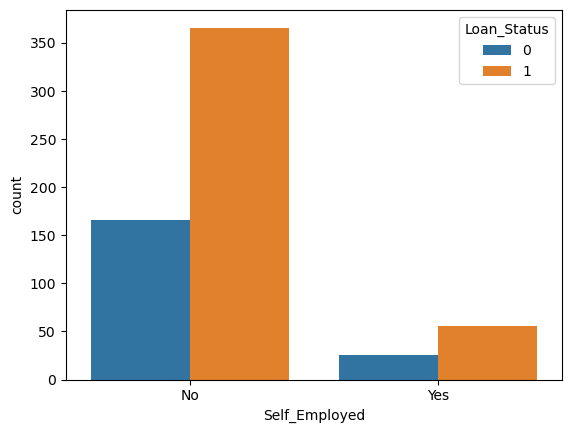

In [23]:
# Self Employed & Loan Status
sns.countplot(x='Self_Employed',hue='Loan_Status',data=loan_dataset)

<Axes: xlabel='Property_Area', ylabel='count'>

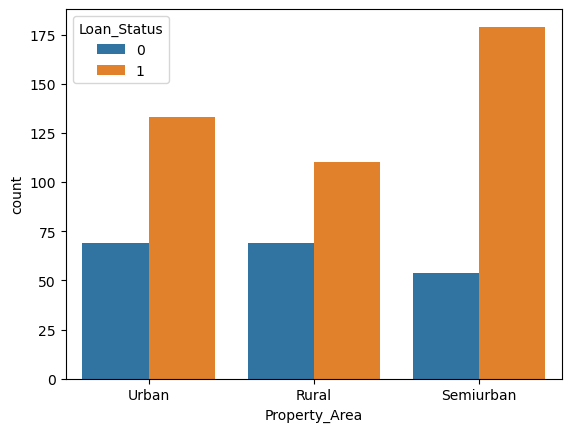

In [24]:
# Property area and Loan status
sns.countplot(x='Property_Area', hue='Loan_Status', data=loan_dataset)

<Axes: xlabel='Credit_History', ylabel='count'>

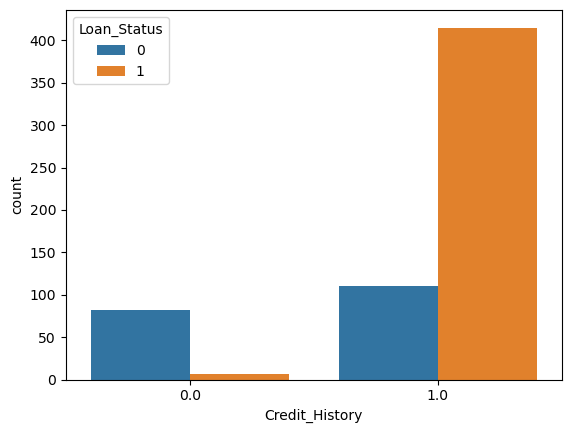

In [25]:
# Credit History and Loan Status
sns.countplot(x='Credit_History' , hue='Loan_Status', data=loan_dataset)

<Axes: xlabel='Dependents', ylabel='count'>

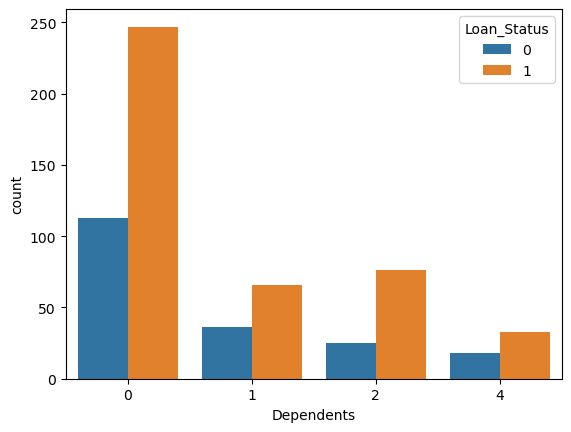

In [26]:
# Dependents and Loan Status
sns.countplot(x='Dependents', hue='Loan_Status',data=loan_dataset)

<Axes: xlabel='Loan_Amount_Term', ylabel='count'>

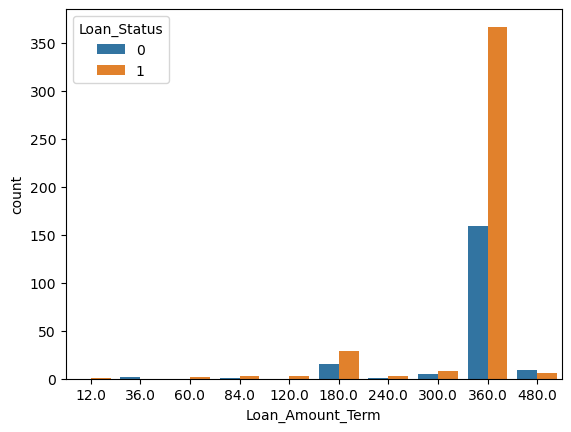

In [27]:
# Loan Amount term and loan status
sns.countplot(x='Loan_Amount_Term', hue='Loan_Status', data=loan_dataset)

In [28]:
# Convert categorical values into numbers
loan_dataset.replace({'Gender':{'Male':1, 'Female':0},'Married': {'No':0, 'Yes':1}, 'Self_Employed': {'No':0,'Yes':1}, 'Education': {'Graduate':1, 'Not Graduate':0}, 'Property_Area': {'Rural':0, 'Semiurban': 1, 'Urban' :2}},inplace=True)


C:\Users\Sanjay\AppData\Local\Temp\ipykernel_2984\1887535367.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({'Gender':{'Male':1, 'Female':0},'Married': {'No':0, 'Yes':1}, 'Self_Employed': {'No':0,'Yes':1}, 'Education': {'Graduate':1, 'Not Graduate':0}, 'Property_Area': {'Rural':0, 'Semiurban': 1, 'Urban' :2}},inplace=True)


In [29]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1


In [30]:
loan_dataset[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']]=StandardScaler().fit_transform(loan_dataset[['ApplicantIncome','CoapplicantIncome', 'LoanAmount']])

In [31]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,1,0,0.072991,-0.554487,-0.211241,360.0,1.0,2,1
1,LP001003,1,1,1,1,0,-0.134412,-0.038732,-0.211241,360.0,1.0,0,0
2,LP001005,1,1,0,1,1,-0.393747,-0.554487,-0.948996,360.0,1.0,2,1
3,LP001006,1,1,0,0,0,-0.462062,0.251980,-0.306435,360.0,1.0,2,1
4,LP001008,1,0,0,1,0,0.097728,-0.554487,-0.056551,360.0,1.0,2,1


In [32]:
# Separating data and label
X= loan_dataset.drop(columns=['Loan_ID', 'Loan_Status'],axis=1)
Y=loan_dataset['Loan_Status']

In [33]:
print (X)
print (Y)

     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        0          0          1              0         0.072991   
1         1        1          1          1              0        -0.134412   
2         1        1          0          1              1        -0.393747   
3         1        1          0          0              0        -0.462062   
4         1        0          0          1              0         0.097728   
..      ...      ...        ...        ...            ...              ...   
609       0        0          0          1              0        -0.410130   
610       1        1          4          1              0        -0.212557   
611       1        1          1          1              0         0.437174   
612       1        1          2          1              0         0.357064   
613       0        0          0          1              1        -0.134412   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

In [34]:
from sklearn.model_selection import train_test_split


In [35]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=2)

In [36]:
from sklearn.linear_model import LogisticRegression


In [37]:
model = LogisticRegression(max_iter=1000)

In [38]:
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
Y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score



In [41]:
accuracy = accuracy_score(Y_test, Y_pred)

print(accuracy)

0.7723577235772358


In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)

print(cm)

[[13 26]
 [ 2 82]]


In [43]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.87      0.33      0.48        39
           1       0.76      0.98      0.85        84

    accuracy                           0.77       123
   macro avg       0.81      0.65      0.67       123
weighted avg       0.79      0.77      0.74       123



In [44]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, Y_train)

Y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(Y_test, Y_pred_dt))

print("\nClassification Report")
print(classification_report(Y_test, Y_pred_dt))

Accuracy: 0.7398373983739838

Confusion Matrix
[[22 17]
 [15 69]]

Classification Report
              precision    recall  f1-score   support

           0       0.59      0.56      0.58        39
           1       0.80      0.82      0.81        84

    accuracy                           0.74       123
   macro avg       0.70      0.69      0.70       123
weighted avg       0.74      0.74      0.74       123



In [46]:
print(Y.value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

rf_model.fit(X_train,Y_train)

Y_pred_rf = rf_model.predict(X_test)

print("Accuracy:",
      accuracy_score(Y_test,Y_pred_rf))

print(confusion_matrix(Y_test,Y_pred_rf))

print(classification_report(Y_test,Y_pred_rf))

Accuracy: 0.7723577235772358
[[14 25]
 [ 3 81]]
              precision    recall  f1-score   support

           0       0.82      0.36      0.50        39
           1       0.76      0.96      0.85        84

    accuracy                           0.77       123
   macro avg       0.79      0.66      0.68       123
weighted avg       0.78      0.77      0.74       123



In [48]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

auc_rf = roc_auc_score(Y_test, y_prob_rf)

print("AUC:", auc_rf)

AUC: 0.7611416361416361


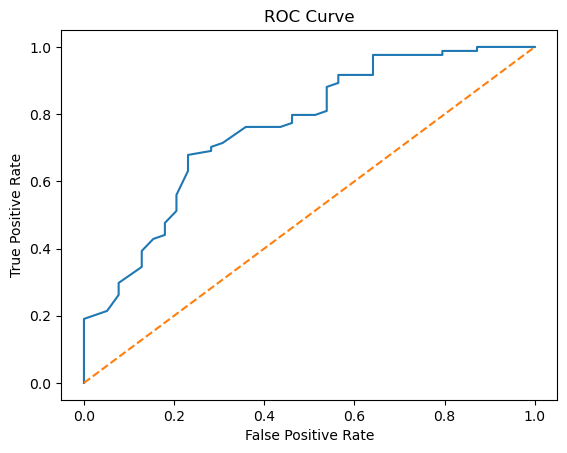

In [49]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr,tpr,_ = roc_curve(Y_test,y_prob_rf)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [50]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

              Feature  Importance
9      Credit_History    0.279356
5     ApplicantIncome    0.198213
7          LoanAmount    0.184269
6   CoapplicantIncome    0.113022
8    Loan_Amount_Term    0.048377
2          Dependents    0.048104
10      Property_Area    0.045293
1             Married    0.026858
3           Education    0.023084
0              Gender    0.018416
4       Self_Employed    0.015009


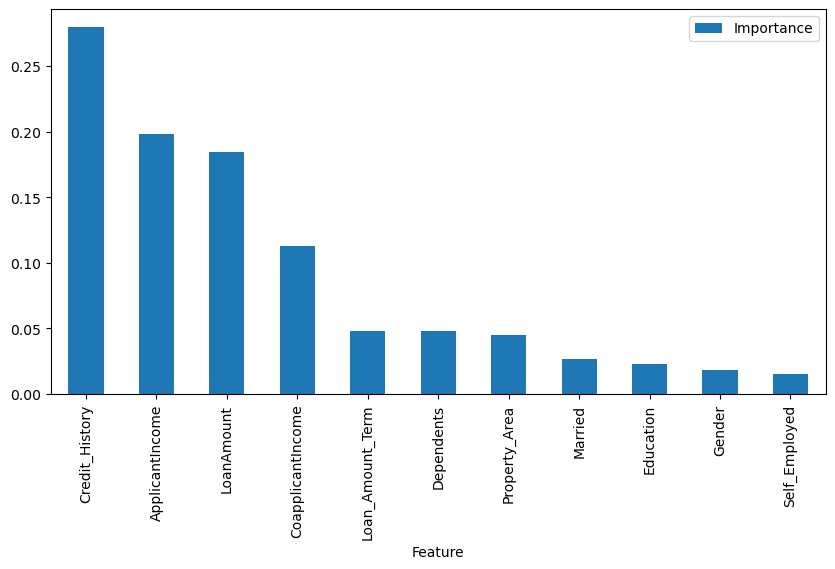

In [51]:
feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.show()

In [53]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression',
             'Decision Tree',
             'Random Forest'],
    'Accuracy':[log_acc, dt_acc, rf_acc]})

print(comparison)

NameError: name 'log_acc' is not defined

In [54]:
from sklearn.metrics import accuracy_score

log_acc = accuracy_score(Y_test, Y_pred)

print(log_acc)

0.7723577235772358


In [55]:
dt_acc = accuracy_score(Y_test, Y_pred_dt)

print(dt_acc)

0.7398373983739838


In [56]:
rf_acc = accuracy_score(Y_test, Y_pred_rf)

print(rf_acc)

0.7723577235772358


In [57]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest'],'Accuracy':[log_acc, dt_acc, rf_acc]})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.772358
1        Decision Tree  0.739837
2        Random Forest  0.772358


In [58]:
from sklearn.metrics import roc_auc_score

y_prob_log = model.predict_proba(X_test)[:,1]

auc_log = roc_auc_score(Y_test, y_prob_log)

print("Logistic Regression AUC:", auc_log)

NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [59]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, Y_train)

Y_pred_log = log_model.predict(X_test)

In [60]:
from sklearn.metrics import roc_auc_score

y_prob_log = log_model.predict_proba(X_test)[:,1]

auc_log = roc_auc_score(Y_test, y_prob_log)

print("Logistic Regression AUC:", auc_log)

Logistic Regression AUC: 0.6599511599511599


In [61]:
from sklearn.metrics import roc_auc_score

y_prob_dt = dt_model.predict_proba(X_test)[:,1]

auc_dt = roc_auc_score(Y_test, y_prob_dt)

print("Decision Tree AUC:", auc_dt)

Decision Tree AUC: 0.6927655677655677


In [62]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

auc_rf = roc_auc_score(Y_test, y_prob_rf)

print("Random Forest AUC:", auc_rf)

Random Forest AUC: 0.7611416361416361


In [63]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression',
             'Decision Tree',
             'Random Forest'],
    'Accuracy':[log_acc, dt_acc, rf_acc],
    'ROC_AUC':[auc_log, auc_dt, auc_rf]
})

print(comparison)

                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.772358  0.659951
1        Decision Tree  0.739837  0.692766
2        Random Forest  0.772358  0.761142


In [64]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
9      Credit_History    0.279356
5     ApplicantIncome    0.198213
7          LoanAmount    0.184269
6   CoapplicantIncome    0.113022
8    Loan_Amount_Term    0.048377
2          Dependents    0.048104
10      Property_Area    0.045293
1             Married    0.026858
3           Education    0.023084
0              Gender    0.018416
4       Self_Employed    0.015009


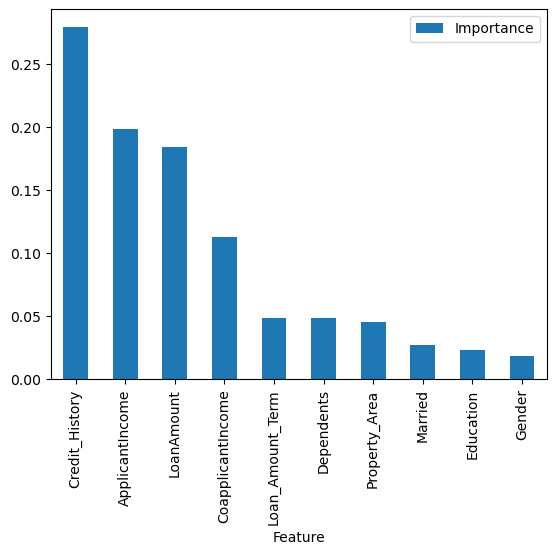

In [65]:
import matplotlib.pyplot as plt

importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.show()